In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import re
import string

In [2]:
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

In [3]:
df_fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
df_true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
df_true.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [6]:
df_fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [7]:
df_fake['class'] = 0
df_true['class'] = 1

In [8]:
print(df_fake.shape)
print(df_true.shape)

(23481, 5)
(21417, 5)


In [9]:
df_fake_manual_testing = df_fake.tail(10)
for i in range(23480, 23470, -1):
    df_fake.drop([i], axis = 0, inplace = True)

df_true_manual_testing = df_true.tail(10)
for i in range(21416, 21406, -1):
    df_true.drop([i], axis = 0, inplace = True)

In [10]:
df_fake.shape, df_true.shape

((23471, 5), (21407, 5))

In [11]:
df_fake_manual_testing['class'] = 0
df_true_manual_testing['class'] = 1

C:\Users\admin\AppData\Local\Temp\ipykernel_5208\1523065411.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fake_manual_testing['class'] = 0
C:\Users\admin\AppData\Local\Temp\ipykernel_5208\1523065411.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_true_manual_testing['class'] = 1


In [12]:
df_fake_manual_testing.head()

,title,text,subject,date,class
23471,Seven Iranians freed in the prisoner swap have...,"21st Century Wire says This week, the historic...",Middle-east,"January 20, 2016",0
23472,#Hashtag Hell & The Fake Left,By Dady Chery and Gilbert MercierAll writers ...,Middle-east,"January 19, 2016",0
23473,Astroturfing: Journalist Reveals Brainwashing ...,Vic Bishop Waking TimesOur reality is carefull...,Middle-east,"January 19, 2016",0
23474,The New American Century: An Era of Fraud,Paul Craig RobertsIn the last years of the 20t...,Middle-east,"January 19, 2016",0
23475,Hillary Clinton: ‘Israel First’ (and no peace ...,Robert Fantina CounterpunchAlthough the United...,Middle-east,"January 18, 2016",0


In [13]:
df_true_manual_testing.head()

,title,text,subject,date,class
21407,"Mata Pires, owner of embattled Brazil builder ...","SAO PAULO (Reuters) - Cesar Mata Pires, the ow...",worldnews,"August 22, 2017",1
21408,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21409,"U.S., North Korea clash at U.N. arms forum on ...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",1
21410,Headless torso could belong to submarine journ...,COPENHAGEN (Reuters) - Danish police said on T...,worldnews,"August 22, 2017",1
21411,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,"August 21, 2017",1


In [14]:
df_merge = pd.concat([df_fake, df_true], axis = 0)
df_merge.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [15]:
df_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [16]:
df = df_merge.drop(['title', 'subject', 'date'], axis = 1)

In [17]:
df.isnull().sum()

text     0
class    0
dtype: int64

In [18]:
df = df.sample(frac = 1)

In [19]:
df.head()

,text,class
16381,CAIRO (Reuters) - Islamic State has claimed re...,1
14873,Rep. Keith Ellison (D-MN) is more than just a ...,0
23150,Shawn Helton 21st Century WireIt s a novel sc...,0
2893,Donald Trump just promised Corporate America t...,0
10634,CNN cut away from a Senate Judiciary Committee...,0


In [20]:
df.reset_index(inplace = True)
df.drop(['index'], axis = 1, inplace = True)

In [21]:
df.columns

Index(['text', 'class'], dtype='object')

In [22]:
df.head()

,text,class
0,CAIRO (Reuters) - Islamic State has claimed re...,1
1,Rep. Keith Ellison (D-MN) is more than just a ...,0
2,Shawn Helton 21st Century WireIt s a novel sc...,0
3,Donald Trump just promised Corporate America t...,0
4,CNN cut away from a Senate Judiciary Committee...,0


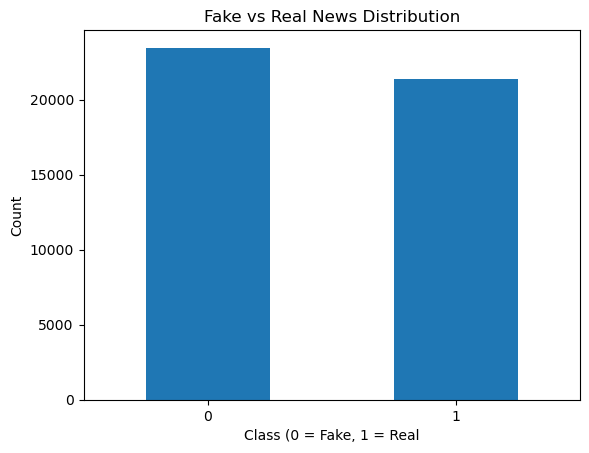

In [53]:
df['class'].value_counts().plot(kind='bar')
plt.title("Fake vs Real News Distribution")
plt.xlabel("Class (0 = Fake, 1 = Real")
plt.xticks(rotation= 0)
plt.ylabel("Count")
plt.show()

In [23]:
def text_preprocess(text): 
    text = text.lower() 
    text = re.sub('\[.*?\]', '', text) 
    text = re.sub("\\W", " ", text) 
    text = re.sub('https?://\S+|www\.\S+', '', text) 
    text = re.sub('<.*?.>+', '', text) 
    text = re.sub('[%s]' %re.escape(string.punctuation), '', text) 
    text = re.sub('\n', '', text) 
    text = re.sub('\w*\d\w*', '', text)
    return text

In [24]:
df['text'] = df['text'].apply(text_preprocess)

In [25]:
X = df['text']
y = df['class']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
vec_train = tfidf_vec.fit_transform(X_train)
vec_test = tfidf_vec.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(vec_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
lr_pred = model_lr.predict(vec_test)

In [30]:
acc_lr = accuracy_score(y_test, lr_pred)
print(f"Accuracy: {acc_lr * 100 : .2f}%")

Accuracy:  98.47%


In [31]:
print("Classification Report\n")
print(classification_report(lr_pred, y_test))

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4650
           1       0.99      0.98      0.98      4326

    accuracy                           0.98      8976
   macro avg       0.98      0.98      0.98      8976
weighted avg       0.98      0.98      0.98      8976



In [32]:
from sklearn.tree import DecisionTreeClassifier

model_dtc = DecisionTreeClassifier()
model_dtc.fit(vec_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
dt_pred = model_dtc.predict(vec_test)

In [34]:
acc_dt = accuracy_score(y_test, dt_pred)
print(f"Accuracy: {acc_dt * 100 : .2f}%")

Accuracy:  99.70%


In [35]:
print("Classification Report\n")
print(classification_report(dt_pred, y_test))

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4672
           1       1.00      1.00      1.00      4304

    accuracy                           1.00      8976
   macro avg       1.00      1.00      1.00      8976
weighted avg       1.00      1.00      1.00      8976



In [36]:
from sklearn.ensemble import GradientBoostingClassifier

model_gbc = GradientBoostingClassifier(random_state = 0)
model_gbc.fit(vec_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
gb_pred = model_gbc.predict(vec_test)

In [38]:
acc_gb = accuracy_score(y_test, gb_pred)
print(f"Accuracy: {acc_gb * 100 : .2f}%")

Accuracy:  99.60%


In [39]:
print("Classification Report\n")
print(classification_report(gb_pred, y_test))

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4645
           1       1.00      0.99      1.00      4331

    accuracy                           1.00      8976
   macro avg       1.00      1.00      1.00      8976
weighted avg       1.00      1.00      1.00      8976



In [40]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state = 0)
model_rf.fit(vec_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_pred = model_rf.predict(vec_test)

In [42]:
acc_rf = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {acc_rf * 100 : .2f}%")

Accuracy:  98.64%


In [43]:
print("Classification Report\n")
print(classification_report(rf_pred, y_test))

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4691
           1       0.98      0.99      0.99      4285

    accuracy                           0.99      8976
   macro avg       0.99      0.99      0.99      8976
weighted avg       0.99      0.99      0.99      8976



In [44]:
import joblib

joblib.dump(model_lr, "logistic_model.pkl")
joblib.dump(model_dtc, "decision_tree_model.pkl")
joblib.dump(model_gbc, "gradient_boosting_model.pkl")
joblib.dump(model_rf, "random_forest_model.pkl")
joblib.dump(tfidf_vec, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [45]:
model_lr = joblib.load("logistic_model.pkl")
model_dtc = joblib.load("decision_tree_model.pkl")
model_gbc = joblib.load("gradient_boosting_model.pkl")
model_rf = joblib.load("random_forest_model.pkl")
tfidf_vec = joblib.load("tfidf_vectorizer.pkl")

def output_label(n):
    if n == 0:
        return "Fake news"
    else:
        return "Not a fake news"
        
def predict_all(text):
    text = text_preprocess(text)
    vec = tfidf_vec.transform([text])
    
    return {
        "LR": output_label(int(model_lr.predict(vec)[0])),
        "DT": output_label(int(model_dtc.predict(vec)[0])),
        "GBC": output_label(int(model_gbc.predict(vec)[0])),
        "RF": output_label(int(model_rf.predict(vec)[0]))
    }

In [46]:
print(predict_all("""According to Reuters, the Indian government announced a new economic policy on Monday aimed at supporting small businesses. Finance Minister Nirmala Sitharaman stated that the policy would create new employment opportunities and boost economic growth."""))

{'LR': 'Not a fake news', 'DT': 'Not a fake news', 'GBC': 'Not a fake news', 'RF': 'Not a fake news'}


In [47]:
print(predict_all("""A viral social media post claims that a new device can generate unlimited free electricity from air, and governments are banning it to maintain control over energy markets."""))

{'LR': 'Fake news', 'DT': 'Fake news', 'GBC': 'Fake news', 'RF': 'Fake news'}
